In [1]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Original chronicle

In [3]:
base_data_path = os.path.join(notebook_dir, '../data')
data_path = os.path.join(base_data_path, 'chronicle2050/data.csv')
original_df = DataProcessing.load_from_file(data_path, 'csv', sep=',')
original_df.rename(columns={'sentence':'Base Sentence', 'label': 'Future-Related Label'}, inplace=True)
original_df

,index,Base Sentence,Future-Related Label
0,0,"By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.",1
1,1,An annual average temperature anomaly value above the 1850-1899 baseline will be published in the Berkeley Earth Global Temperature series as 2.0C or higher on or before the 2037 value (published in 2038).,1
2,2,Private Nonfarm business productivity growth will average over 1.8 percent per year from the first quarter (Q1) of 2020 to the last quarter of 2029 (Q4).,1
3,3,"No Republican will be President of the USA before December 30, 2039.",1
4,4,The market capitalization of Berkshire Hathaway will be greater than Tesla on Warren Buffett's 100th birthday.,1
...,...,...,...
6397,2540,"Many major technology players are [TeleNav Inc., TomTom International BV, Trimble Navigation Ltd., ARI, Autotrac, Blue Tree Systems, BSM Wireless, CarrierWeb, Celtrak, Chevin, Ctrack, DriverTech, EDT, FieldLogix, Fleetcor Technologies, Fleetio, Garmin International, GPS Integrated, GPSTrackIt are going out of business",0
6398,2541,"WaterIQ Technologies, the leader in next-generation ultrasonic solutions to combat harmful algae and biofilm without the use of chemicals, today announced the appointment of Rick Clark as Director of Environmental and Regulatory Affairs.",0
6399,2542,The Business Research Company's 'Clean Coal Technology Global Market Report 2023' is a comprehensive source of information that covers every facet of the clean coal technology market.,0
6400,2543,'Prophecy Market Insights offers a 20% discount on Assisted Living Technologies Market Reports on Single Assisted Living Technologies is a tool which helps aged adults with disabilities to perform daily activities and to continue to live at home and to prevent the need for long-term care.,0


In [4]:
original_df

,index,Base Sentence,Future-Related Label
0,0,"By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.",1
1,1,An annual average temperature anomaly value above the 1850-1899 baseline will be published in the Berkeley Earth Global Temperature series as 2.0C or higher on or before the 2037 value (published in 2038).,1
2,2,Private Nonfarm business productivity growth will average over 1.8 percent per year from the first quarter (Q1) of 2020 to the last quarter of 2029 (Q4).,1
3,3,"No Republican will be President of the USA before December 30, 2039.",1
4,4,The market capitalization of Berkshire Hathaway will be greater than Tesla on Warren Buffett's 100th birthday.,1
...,...,...,...
6397,2540,"Many major technology players are [TeleNav Inc., TomTom International BV, Trimble Navigation Ltd., ARI, Autotrac, Blue Tree Systems, BSM Wireless, CarrierWeb, Celtrak, Chevin, Ctrack, DriverTech, EDT, FieldLogix, Fleetcor Technologies, Fleetio, Garmin International, GPS Integrated, GPSTrackIt are going out of business",0
6398,2541,"WaterIQ Technologies, the leader in next-generation ultrasonic solutions to combat harmful algae and biofilm without the use of chemicals, today announced the appointment of Rick Clark as Director of Environmental and Regulatory Affairs.",0
6399,2542,The Business Research Company's 'Clean Coal Technology Global Market Report 2023' is a comprehensive source of information that covers every facet of the clean coal technology market.,0
6400,2543,'Prophecy Market Insights offers a 20% discount on Assisted Living Technologies Market Reports on Single Assisted Living Technologies is a tool which helps aged adults with disabilities to perform daily activities and to continue to live at home and to prevent the need for long-term care.,0



LOAD CHRONICLE2050 DATASET
Loading from: /Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/notebook_experiments/../data/chronicle2050/annotators/chronicle2050-shawnick-binary-v7.csv
Loaded shape: (6402, 2)


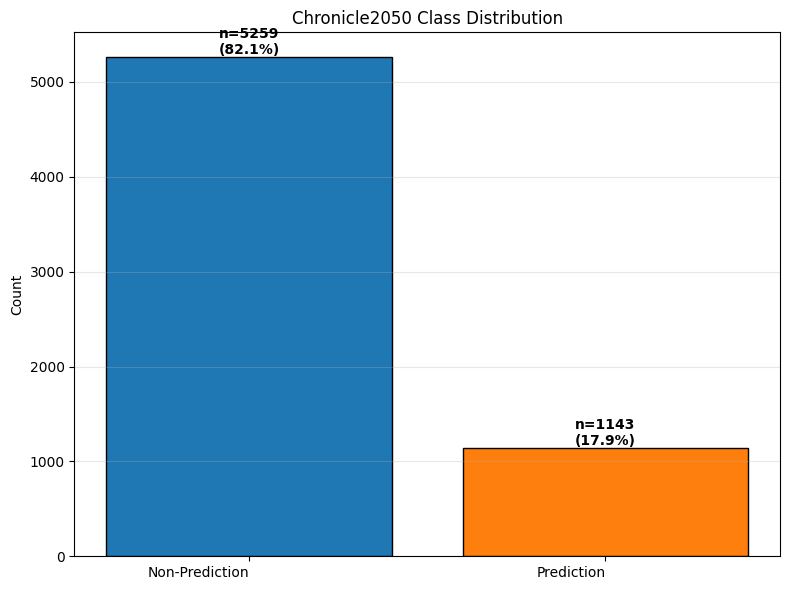

Columns: ['Base Sentence', 'Ground Truth']

Ground Truth distribution:
Ground Truth
0    5259
1    1143
Name: count, dtype: int64

Preview:
                                                                                                                                                                                                                                                          Base Sentence  \
0                                                                                                                                                                    Christina Jackson, formerly of Tetsu, and Benjamin Leung, formerly of Manhatta, prepared the food.   
1                                                                                                                                         The diverse group of backers includes an evangelical preacher who last voted for a Democratic presidential candidate in 1976.   
2                                                          

,Base Sentence,Ground Truth,Dataset Name
0,"Christina Jackson, formerly of Tetsu, and Benjamin Leung, formerly of Manhatta, prepared the food.",1,chronicle2050
1,The diverse group of backers includes an evangelical preacher who last voted for a Democratic presidential candidate in 1976.,1,chronicle2050
2,"WASHINGTON — President Biden on Thursday warned Americans to leave Ukraine, saying that U.S. troops would not be dispatched to retrieve them should Russia invade.",1,chronicle2050
3,“I haven’t slept for three nights.,0,chronicle2050
4,"Kayleigh McEnany was talking about Barack Obama, not Donald Trump.",0,chronicle2050
...,...,...,...
6397,"It is southwest, not northeast, of Tonga.",0,chronicle2050
6398,"The leaked Supreme Court draft opinion indicating that the Supreme Court might overturn Roe v. Wade, heralding a seismic shift in American politics and law, has left many Americans wondering what comes next.",1,chronicle2050
6399,"Nordstrom's last sale of 2019 has major markdowns on beloved brands like Madewell, Natori and Stuart Weitzman.",0,chronicle2050
6400,The company should consider implementing a new strategy to improve its profits.,0,chronicle2050


In [5]:
our_df = DataProcessing.load_chronicle2050_dataset(notebook_dir, predictions_only=False)
our_df

In [7]:
# our_df = our_df.loc[: , ["Base Sentence", "Ground Truth", "shawnick_reasoning"]]
our_df = our_df.loc[: , ["Base Sentence", "Ground Truth"]]
our_df

,Base Sentence,Ground Truth
0,"Christina Jackson, formerly of Tetsu, and Benjamin Leung, formerly of Manhatta, prepared the food.",1
1,The diverse group of backers includes an evangelical preacher who last voted for a Democratic presidential candidate in 1976.,1
2,"WASHINGTON — President Biden on Thursday warned Americans to leave Ukraine, saying that U.S. troops would not be dispatched to retrieve them should Russia invade.",1
3,“I haven’t slept for three nights.,0
4,"Kayleigh McEnany was talking about Barack Obama, not Donald Trump.",0
...,...,...
6397,"It is southwest, not northeast, of Tonga.",0
6398,"The leaked Supreme Court draft opinion indicating that the Supreme Court might overturn Roe v. Wade, heralding a seismic shift in American politics and law, has left many Americans wondering what comes next.",1
6399,"Nordstrom's last sale of 2019 has major markdowns on beloved brands like Madewell, Natori and Stuart Weitzman.",0
6400,The company should consider implementing a new strategy to improve its profits.,0


In [8]:
# Source - https://stackoverflow.com/a/41463139
# Posted by jezrael, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-15, License - CC BY-SA 3.0

df = pd.merge(original_df, our_df, left_on='Base Sentence', right_on='Base Sentence', how='left')
df

,index,Base Sentence,Future-Related Label,Ground Truth
0,0,"By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.",1,1.0
1,1,An annual average temperature anomaly value above the 1850-1899 baseline will be published in the Berkeley Earth Global Temperature series as 2.0C or higher on or before the 2037 value (published in 2038).,1,1.0
2,2,Private Nonfarm business productivity growth will average over 1.8 percent per year from the first quarter (Q1) of 2020 to the last quarter of 2029 (Q4).,1,1.0
3,3,"No Republican will be President of the USA before December 30, 2039.",1,1.0
4,4,The market capitalization of Berkshire Hathaway will be greater than Tesla on Warren Buffett's 100th birthday.,1,1.0
...,...,...,...,...
6397,2540,"Many major technology players are [TeleNav Inc., TomTom International BV, Trimble Navigation Ltd., ARI, Autotrac, Blue Tree Systems, BSM Wireless, CarrierWeb, Celtrak, Chevin, Ctrack, DriverTech, EDT, FieldLogix, Fleetcor Technologies, Fleetio, Garmin International, GPS Integrated, GPSTrackIt are going out of business",0,0.0
6398,2541,"WaterIQ Technologies, the leader in next-generation ultrasonic solutions to combat harmful algae and biofilm without the use of chemicals, today announced the appointment of Rick Clark as Director of Environmental and Regulatory Affairs.",0,0.0
6399,2542,The Business Research Company's 'Clean Coal Technology Global Market Report 2023' is a comprehensive source of information that covers every facet of the clean coal technology market.,0,0.0
6400,2543,'Prophecy Market Insights offers a 20% discount on Assisted Living Technologies Market Reports on Single Assisted Living Technologies is a tool which helps aged adults with disabilities to perform daily activities and to continue to live at home and to prevent the need for long-term care.,0,NaN


>- 1, 1 => Future and Prediction
>- 1, 0 => Future and NOT Prediction
>- 0, 1 => NOT Future, but is Prediction
>- 0, 0 => NOT Future and NOT Prediction

In [9]:
fp = []
fnotp = []
pnotf = []
notfnotp = []

for idx, row in df.iterrows():
    sentence = row['Base Sentence']
    frl = row['Future-Related Label']
    pl = row['Ground Truth']

    if pd.isna(pl):
        continue
    else:

        if frl == 1 and pl == 1:
            fp_row = {
                'Base Sentence': sentence,
                'Future-Related Label': frl,
                'Prediction Label': pl,
                'Class': 'Future-Related and Prediction'
            }
            fp.append(fp_row)

        elif frl == 1 and pl == 0:
            fnotp_row = {
                'Base Sentence': sentence,
                'Future-Related Label': frl,
                'Prediction Label': pl,
                'Class': 'Future-Related and NOT Prediction'
            }
            fnotp.append(fnotp_row)

        elif frl == 0 and pl == 1:
            pnotf_row = {
                'Base Sentence': sentence,
                'Future-Related Label': frl,
                'Prediction Label': pl,
                'Class': 'NOT Future-Related, but Prediction'
            }
            pnotf.append(pnotf_row)

        elif frl == 0 and pl == 0:
            notfnotp_row = {
                'Base Sentence': sentence,
                'Future-Related Label': frl,
                'Prediction Label': pl,
                'Class': 'NOT Future-Related and NOT Prediction'
            }
            notfnotp.append(notfnotp_row)

fp, fnotp, pnotf, notfnotp

fp_df = pd.DataFrame(fp)
fnotp_df = pd.DataFrame(fnotp)
pnotf_df = pd.DataFrame(pnotf)
notfnotp_df = pd.DataFrame(notfnotp)

grouped_df = DataProcessing.concat_dfs([fp_df, fnotp_df, pnotf_df, notfnotp_df])
grouped_df

,Base Sentence,Future-Related Label,Prediction Label,Class
0,"By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.",1,1.0,Future-Related and Prediction
1,An annual average temperature anomaly value above the 1850-1899 baseline will be published in the Berkeley Earth Global Temperature series as 2.0C or higher on or before the 2037 value (published in 2038).,1,1.0,Future-Related and Prediction
2,Private Nonfarm business productivity growth will average over 1.8 percent per year from the first quarter (Q1) of 2020 to the last quarter of 2029 (Q4).,1,1.0,Future-Related and Prediction
3,"No Republican will be President of the USA before December 30, 2039.",1,1.0,Future-Related and Prediction
4,The market capitalization of Berkshire Hathaway will be greater than Tesla on Warren Buffett's 100th birthday.,1,1.0,Future-Related and Prediction
...,...,...,...,...
6386,"Ev Dynamics (Holdings) Limited (the ""Company"", Stock Code: 476, together with its subsidiaries, collectively ""Ev Dynamics"" or the ""Group""), a leading developer and manufacturer of new energy vehicles (NEVs), announced that its wholly-owned subsidiary China Dynamics New Energy Technology Company Limited has signed a strategic cooperation agreement with Zhongguancun Trust and Integrity Alliance for Technology and Innovation (""Zhongguancun Technology"";) and Shenzhen Qinghang Zhixing Technology Company Limited (""Shenzhen Qinghang Zhixing"";) to jointly promote the application of autonomous driving technologies and seize market opportunities brought by related technologies rapidly developing and heading for commercialization.",0,0.0,NOT Future-Related and NOT Prediction
6387,"Many major technology players are [TeleNav Inc., TomTom International BV, Trimble Navigation Ltd., ARI, Autotrac, Blue Tree Systems, BSM Wireless, CarrierWeb, Celtrak, Chevin, Ctrack, DriverTech, EDT, FieldLogix, Fleetcor Technologies, Fleetio, Garmin International, GPS Integrated, GPSTrackIt are going out of business",0,0.0,NOT Future-Related and NOT Prediction
6388,"WaterIQ Technologies, the leader in next-generation ultrasonic solutions to combat harmful algae and biofilm without the use of chemicals, today announced the appointment of Rick Clark as Director of Environmental and Regulatory Affairs.",0,0.0,NOT Future-Related and NOT Prediction
6389,The Business Research Company's 'Clean Coal Technology Global Market Report 2023' is a comprehensive source of information that covers every facet of the clean coal technology market.,0,0.0,NOT Future-Related and NOT Prediction


In [10]:
fnotp_df

,Base Sentence,Future-Related Label,Prediction Label,Class
0,Slaughterhouses will be banned in the United Kingdom by 2050.,1,0.0,Future-Related and NOT Prediction
1,"Clinicians and neuroscientists will develop well validated brain-activity measurement technologies establishing with a high degree of certainty whether individual human subjects, such as anesthetized and neurological patients, are, at that moment, conscious.",1,0.0,Future-Related and NOT Prediction
2,Trips may be point to point outside of the city center with no requirement for any passenger to take over manual control of the vehicle.,1,0.0,Future-Related and NOT Prediction
3,"Over a ten-year period commencing on January 1, 2008, and ending on December 31, 2017, the S&P 500 will outperform a portfolio of funds of hedge funds, when performance is measured on a basis net of fees, costs and expenses.",1,0.0,Future-Related and NOT Prediction
4,Neither major U. S. political party will hold conventions or indeed primaries to select their 2012 Presidential nominees.,1,0.0,Future-Related and NOT Prediction
...,...,...,...,...
2084,An auto manufacturing plant in Huntsville has plans to use more renewable energy.,1,0.0,Future-Related and NOT Prediction
2085,"Wednesday, Toyota Alabama announced it will be building a 168-acre solar farm, adjacent to the Huntsville plant off of Pulaski Pike.",1,0.0,Future-Related and NOT Prediction
2086,Toyota rethinks its EV strategy for the future.,1,0.0,Future-Related and NOT Prediction
2087,"The new CEO, Koji Sato, has a big interest in expanding Toyota's place in the electric vehicle market.",1,0.0,Future-Related and NOT Prediction


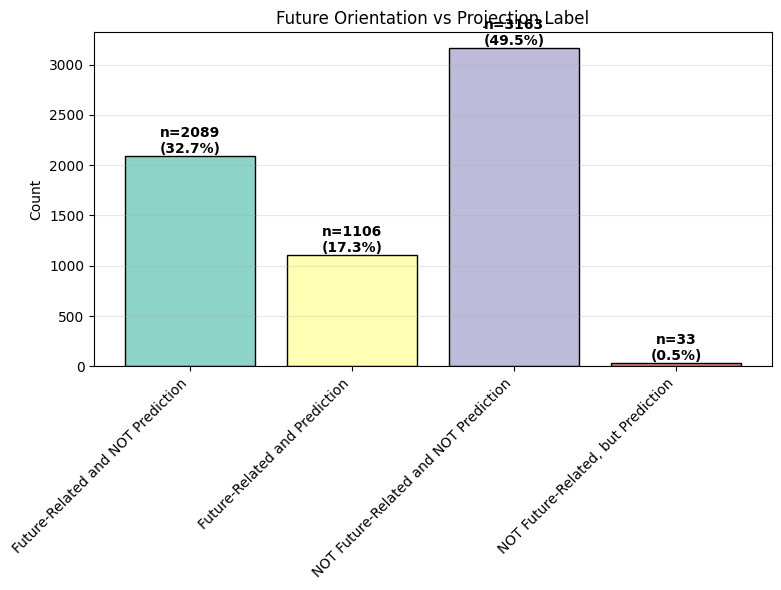

In [11]:
DataVisualizing.plot_class_distribution(
    df=grouped_df,
    label_col='Class',
    title='Future Orientation vs Projection Label'
    )

In [12]:
grouped_df

,Base Sentence,Future-Related Label,Prediction Label,Class
0,"By January 1st, 2037, Tesla will have been the first company with 1 million vehicles that are capable of SAE Level 4 autonomy on over 90% of public roads in the contiguous United States, with human-level safety or better, and this capability will be usable by the general public commercially.",1,1.0,Future-Related and Prediction
1,An annual average temperature anomaly value above the 1850-1899 baseline will be published in the Berkeley Earth Global Temperature series as 2.0C or higher on or before the 2037 value (published in 2038).,1,1.0,Future-Related and Prediction
2,Private Nonfarm business productivity growth will average over 1.8 percent per year from the first quarter (Q1) of 2020 to the last quarter of 2029 (Q4).,1,1.0,Future-Related and Prediction
3,"No Republican will be President of the USA before December 30, 2039.",1,1.0,Future-Related and Prediction
4,The market capitalization of Berkshire Hathaway will be greater than Tesla on Warren Buffett's 100th birthday.,1,1.0,Future-Related and Prediction
...,...,...,...,...
6386,"Ev Dynamics (Holdings) Limited (the ""Company"", Stock Code: 476, together with its subsidiaries, collectively ""Ev Dynamics"" or the ""Group""), a leading developer and manufacturer of new energy vehicles (NEVs), announced that its wholly-owned subsidiary China Dynamics New Energy Technology Company Limited has signed a strategic cooperation agreement with Zhongguancun Trust and Integrity Alliance for Technology and Innovation (""Zhongguancun Technology"";) and Shenzhen Qinghang Zhixing Technology Company Limited (""Shenzhen Qinghang Zhixing"";) to jointly promote the application of autonomous driving technologies and seize market opportunities brought by related technologies rapidly developing and heading for commercialization.",0,0.0,NOT Future-Related and NOT Prediction
6387,"Many major technology players are [TeleNav Inc., TomTom International BV, Trimble Navigation Ltd., ARI, Autotrac, Blue Tree Systems, BSM Wireless, CarrierWeb, Celtrak, Chevin, Ctrack, DriverTech, EDT, FieldLogix, Fleetcor Technologies, Fleetio, Garmin International, GPS Integrated, GPSTrackIt are going out of business",0,0.0,NOT Future-Related and NOT Prediction
6388,"WaterIQ Technologies, the leader in next-generation ultrasonic solutions to combat harmful algae and biofilm without the use of chemicals, today announced the appointment of Rick Clark as Director of Environmental and Regulatory Affairs.",0,0.0,NOT Future-Related and NOT Prediction
6389,The Business Research Company's 'Clean Coal Technology Global Market Report 2023' is a comprehensive source of information that covers every facet of the clean coal technology market.,0,0.0,NOT Future-Related and NOT Prediction


In [17]:
filt_nfrbp = grouped_df['Class'] =='NOT Future-Related, but Prediction'
grouped_df[filt_nfrbp]

,Base Sentence,Future-Related Label,Prediction Label,Class
3195,The diverse group of backers includes an evangelical preacher who last voted for a Democratic presidential candidate in 1976.,0,1.0,"NOT Future-Related, but Prediction"
3196,"Politics editor Chris Stirewalt said the president made ""a tactical error” suggesting the 2020 election be delayed.",0,1.0,"NOT Future-Related, but Prediction"
3197,"“If I make a lot of money, you make a lot of money,"" the senator and 2020 hopeful said of his millionaire status.",0,1.0,"NOT Future-Related, but Prediction"
3198,"As humans use visual aids as their primary sense of perception, the ability to ""see"" and recognize the world is imperative for machines too",0,1.0,"NOT Future-Related, but Prediction"
3199,"Smaller and cheaper than current drones, these remotely piloted aircraft systems (RPAS) are the next step of the exponential price-performance adoption curve drones received over the last few years",0,1.0,"NOT Future-Related, but Prediction"
3200,"Artificial intelligence is an emerging technology that has the potential to transform many industries, including healthcare and finance.",0,1.0,"NOT Future-Related, but Prediction"
3201,Autonomous vehicles have the potential to revolutionize transportation by reducing accidents and traffic congestion.,0,1.0,"NOT Future-Related, but Prediction"
3202,"Cybersecurity is an increasingly important concern in today's digital age, as hackers and cybercriminals become more sophisticated.",0,1.0,"NOT Future-Related, but Prediction"
3203,The basketball player could have scored more points if he had practiced more.,0,1.0,"NOT Future-Related, but Prediction"
3204,The scientist could have discovered a cure for cancer if he had more funding.,0,1.0,"NOT Future-Related, but Prediction"


In [ ]:
/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/data/combined_datasets/emnlp_2026/emnlp_2026.csv

'/Users/detraviousjamaribrinkley/Documents/Development/research_labs/uf_ds/predictions/data/combined_datasets/emnlp_2026.csv'